# Setup FCN model

We generate the inputs to `DetectTargetLayer` , to manipulate and modify the layer to procduce a modified `output_rois` 
containing false positives. 
This will be passed on the the heatmap layer, and through there will become the input to FCN.

## setup MRCNN and FCN models and load weights

In [4]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
%matplotlib inline
%load_ext autoreload
%autoreload 2
import sys,os, pprint
pp = pprint.PrettyPrinter(indent=2, width=100)
print('Current working dir: ', os.getcwd())
if '..' not in sys.path:
    print("appending '..' to sys.path")
    sys.path.append('..')
    
import numpy as np
# import matplotlib as plt
import mrcnn.utils     as utils
import mrcnn.visualize as visualize
import mrcnn.visualize_2 as vis2
import mrcnn.visualize_3 as vis3

from mrcnn.prep_notebook import build_fcn_inference_pipeline_newshapes, build_mrcnn_inference_pipeline_newshapes,run_mrcnn_detection
from mrcnn.visualize     import display_training_batch
from mrcnn.prep_notebook import get_inference_batch, get_image_batch, run_mrcnn_detection, run_fcn_detection
from mrcnn.newshapes     import prep_newshape_dataset

# WEIGHT_FILE = 'F:/models/train_fcn8_coco_adam/fcn20181109T0000/fcn_2298.h5'

##------------------------------------------------------------------------------------
## Parse command line arguments
##------------------------------------------------------------------------------------
parser = utils.command_line_parser()
input_parms  =" --batch_size     1  "
input_parms +=" --dataset        newshapes2"
input_parms +=" --mrcnn_logs_dir train_mrcnn "
input_parms +=" --fcn_logs_dir   train_fcn8L2_BCE "
input_parms +=" --mrcnn_model    last "
input_parms +=" --fcn_model      last "
input_parms +=" --fcn_layer      all"
input_parms +=" --fcn_arch       fcn8L2 " 

# input_parms +=" --mrcnn_model      " + WEIGHT_FILE + "  "
# input_parms +=" --fcn_model      " + WEIGHT_FILE + "  "
input_parms +=" --fcn_layer      all"
input_parms +=" --fcn_arch       fcn8 " 
input_parms +=" --sysout         screen "
input_parms +=" --scale_factor   1"

args = parser.parse_args(input_parms.split())
utils.display_input_parms(args)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Current working dir:  /home/kbardool/git_projs/mrcnn3/notebooks

   Arguments passed :
   --------------------
   batch_size                     1
   coco_classes                   None
   dataset                        newshapes2
   epochs                         1
   evaluate_method                1
   fcn_arch                       FCN8
   fcn_bce_loss_class             0
   fcn_bce_loss_method            1
   fcn_layers                     ['all']
   fcn_logs_dir                   train_fcn8L2_BCE
   fcn_losses                     fcn_BCE_loss
   fcn_model                      last
   last_epoch                     0
   lr                             0.001
   mrcnn_exclude_layers           None
   mrcnn_layers                   ['mrcnn', 'fpn', 'rpn']
   mrcnn_logs_dir                 train_mrcnn
   mrcnn_model                    last
   new_log_folder                 False
   opt               

In [5]:
mrcnn_model, fcn_model = build_fcn_inference_pipeline_newshapes(args = args,verbose = 1)

MODE IS: inference

--> Execution started at: 06-22-2019 @ 10:12:10
    Tensorflow Version: 1.8.0   Keras Version : 2.1.6 
    Build_mrcnn_inference_pipeline_newshapes MODE is : inference

   Arguments passed :
   --------------------
   batch_size                     1
   coco_classes                   None
   dataset                        newshapes2
   epochs                         1
   evaluate_method                1
   fcn_arch                       FCN8
   fcn_bce_loss_class             0
   fcn_bce_loss_method            1
   fcn_layers                     ['all']
   fcn_logs_dir                   train_fcn8L2_BCE
   fcn_losses                     fcn_BCE_loss
   fcn_model                      last
   last_epoch                     0
   lr                             0.001
   mrcnn_exclude_layers           None
   mrcnn_layers                   ['mrcnn', 'fpn', 'rpn']
   mrcnn_logs_dir                 train_mrcnn
   mrcnn_model                    last
   new_log_folder        

    mrcnn_class_conv1              :  shape: (?, 1000, 1, 1, 1024)  KB.shape:(None, 1000, 1, 1, 1024)  Keras Tensor: True
    mrcnn_class_bn1                :  shape: (?, 1000, 1, 1, 1024)  KB.shape:(None, 1000, 1, 1, 1024)  Keras Tensor: True
    mrcnn_class_relu1              :  shape: (?, 1000, 1, 1, 1024)  KB.shape:(None, 1000, 1, 1, 1024)  Keras Tensor: True
                                   
    mrcnn_class_conv2              :  shape: (?, 1000, 1, 1, 1024)  KB.shape:(None, 1000, 1, 1, 1024)  Keras Tensor: True
    mrcnn_class_bn2                :  shape: (?, 1000, 1, 1, 1024)  KB.shape:(None, 1000, 1, 1, 1024)  Keras Tensor: True
    mrcnn_class_relu2              :  shape: (?, 1000, 1, 1, 1024)  KB.shape:(None, 1000, 1, 1, 1024)  Keras Tensor: True
                                   
    pool_squeeze(Shared)           :  shape: (?, 1000, 1024)       KB.shape:(None, 1000, 1024)    Keras Tensor: True
    mrcnn_class_logits             :  shape: (?, 1000, 9)          KB.shape:(No

    Weights file loaded: /home/kbardool/models_newshapes2/train_mrcnn/mrcnn20190318T0000/mrcnn_0332.h5 
MRCNN  MODEL Load weight file COMPLETE 
>>> Initialize Paths
 Linx  Linux

   Arguments passed :
   --------------------
   batch_size                     1
   coco_classes                   None
   dataset                        newshapes2
   epochs                         1
   evaluate_method                1
   fcn_arch                       FCN8
   fcn_bce_loss_class             0
   fcn_bce_loss_method            1
   fcn_layers                     ['all']
   fcn_logs_dir                   train_fcn8L2_BCE
   fcn_losses                     fcn_BCE_loss
   fcn_model                      last
   last_epoch                     0
   lr                             0.001
   mrcnn_exclude_layers           None
   mrcnn_layers                   ['mrcnn', 'fpn', 'rpn']
   mrcnn_logs_dir                 train_mrcnn
   mrcnn_model                    last
   new_log_folder                 F

    old_style_scores               :  shape: (?, 3)                KB.shape:(None, 3)             Keras Tensor: False
    alt_scores_1                   :  shape: (?, 3)                KB.shape:(None, 3)             Keras Tensor: False
    alt_scores_1_scattered         :  shape: (1, 9, 64, 3)         KB.shape:(1, 9, 64, 3)         Keras Tensor: False
    alt_scores_1_norm(by_class)    :  shape: (1, 9, 64, 3)         KB.shape:(1, 9, 64, 3)         Keras Tensor: False
    alt_scores_1_norm(by_image)    :  shape: (?, 3)                KB.shape:(None, 3)             Keras Tensor: False
    Normalize heatmap within each class !-------------------------------------
    in_heatmap                     :  shape: (?, 128, 128, 9)      KB.shape:(None, 128, 128, 9)   Keras Tensor: True
    in_heatmap_norm                :  shape: (?, 9, 128, 128)      KB.shape:(None, 9, 128, 128)   Keras Tensor: False
    normalizer shape               :  shape: (?, 9, 1, 1)          KB.shape:(None, 9, 1, 1)     

    Weights file loaded: /home/kbardool/models_newshapes2/train_fcn8L2_BCE/fcn20190323T0000/fcn_0266.h5 
FCN  MODEL Load weight file COMPLETE 


## Load Weights 

In [6]:
MRCNN_DIR_WEIGHTS =  '/home/kbardool/models_newshapes2/train_mrcnn/mrcnn20190318T0000' 
mrcnn_files   = ['initialization', 
               'mrcnn_0001.h5', 'mrcnn_0020.h5', 'mrcnn_0041.h5', 'mrcnn_0060.h5', 'mrcnn_0092.h5', 
               'mrcnn_0116.h5', 'mrcnn_0154.h5', 'mrcnn_0174.h5', 'mrcnn_0201.h5', 'mrcnn_0223.h5', 
               'mrcnn_0243.h5', 'mrcnn_0332.h5']

# DIR_WEIGHTS =  'F:/models_newshapes/train_fcn8_l2_newshapes/fcn20181224T0000'
# files   = ['fcn_0001.h5', 'fcn_0150.h5', 'fcn_0346.h5', 'fcn_0421.h5',
#            'fcn_0450.h5', 'fcn_0482.h5', 'fcn_0521.h5', 'fcn_0610.h5',
#            'fcn_0687.h5', 'fcn_0793.h5', 'fcn_0821.h5', 'fcn_0940.h5',
#            'fcn_1012.h5', 'fcn_1127.h5', 'fcn_1644.h5', 'fcn_1776.h5',
#            'fcn_1848.h5', 'fcn_2017.h5', 'fcn_2084.h5', 'fcn_x0434.h5', 'fcn_x0419.h5']

FCN_DIR_WEIGHTS =  '/home/kbardool/models_newshapes2/train_fcn8L2_BCE/fcn20190323T0000' ### Training with LR=0.00001, MSE Loss NO L2 Regularization
fcn_files= ['fcn_0001.h5', 'fcn_0002.h5', 'fcn_0003.h5', 'fcn_0004.h5', 
            'fcn_0005.h5', 'fcn_0006.h5', 'fcn_0008.h5', 'fcn_0009.h5', 
            'fcn_0012.h5', 'fcn_0016.h5', 'fcn_0018.h5', 'fcn_0019.h5', 
            'fcn_0021.h5', 'fcn_0022.h5', 'fcn_0023.h5', 'fcn_0024.h5', 
            'fcn_0033.h5', 'fcn_0039.h5', 'fcn_0042.h5', 'fcn_0044.h5', 
            'fcn_0077.h5', 'fcn_0089.h5', 'fcn_0170.h5', 'fcn_0177.h5',
            'fcn_0253.h5', 'fcn_0266.h5']

### Load mrcnn weight file

In [ ]:
FILE_IDX = 
weights_path = os.path.join(MRCNN_DIR_WEIGHTS  , mrcnn_files[FILE_IDX])
print("Loading weights ", weights_path)
mrcnn_model.load_model_weights(weights_path)

### Load fcn weight file

In [6]:
FILE_IDX = -1
weights_path = os.path.join(FCN_DIR_WEIGHTS  , fcn_files[FILE_IDX])
print("Loading weights ", weights_path)
fcn_model.load_model_weights(weights_path)

Loading weights  /home/kbardool/models_newshapes2/train_fcn8L2_BCE1/fcn20190323T0000/fcn_0089.h5
-----------------------------------------------
 Load Model with init parm: [ /home/kbardool/models_newshapes2/train_fcn8L2_BCE1/fcn20190323T0000/fcn_0089.h5 ]
-----------------------------------------------
 ---> Explicit weight file
>>> load_weights() from : /home/kbardool/models_newshapes2/train_fcn8L2_BCE1/fcn20190323T0000/fcn_0089.h5
    Weights file loaded: /home/kbardool/models_newshapes2/train_fcn8L2_BCE1/fcn20190323T0000/fcn_0089.h5 
FCN  MODEL Load weight file COMPLETE 


# Load / Build test datasets

In [7]:
# del dataset_train, dataset_val, train_generator, val_generator
# dataset_test , test_generator   = prep_newshape_dataset( mrcnn_model.config,  1000, generator=True)
# with open('newshapes_dataset_1000_B.pkl', 'wb') as outfile:
#     pickle.dump(dataset_test, outfile)
## -- OR --
## -- OR --
import pickle
with open(os.path.join(mrcnn_model.config.DIR_DATASET,"newshapes2_test_dataset_1000_A.pkl"), 'rb') as infile:
    dataset_test = pickle.load(infile)
print(type(dataset_test))    
class_names = dataset_test.class_names

dataset_test.display_active_class_info()
print("Testing Dataset Image Count: {}".format(len(dataset_test.image_ids)))
print("Testing Dataset Class Count: {}".format(dataset_test.num_classes))
print(len(dataset_test.image_ids))    
class_names = dataset_test.class_names

<class 'mrcnn.newshapes2.NewImagesDataset'>
 Active Class Information 
--------------------------
[1, 2, 3, 4, 5, 6, 7, 8]
internal_class:  1 ext_cls: 1 category-name: None - person
internal_class:  2 ext_cls: 2 category-name: None - car
internal_class:  3 ext_cls: 3 category-name: None - sun
internal_class:  4 ext_cls: 4 category-name: None - building
internal_class:  5 ext_cls: 5 category-name: None - tree
internal_class:  6 ext_cls: 6 category-name: None - cloud
internal_class:  7 ext_cls: 7 category-name: None - airplane
internal_class:  8 ext_cls: 8 category-name: None - truck
Testing Dataset Image Count: 1000
Testing Dataset Class Count: 9
1000


## Display Images

###  Display some images from dataset

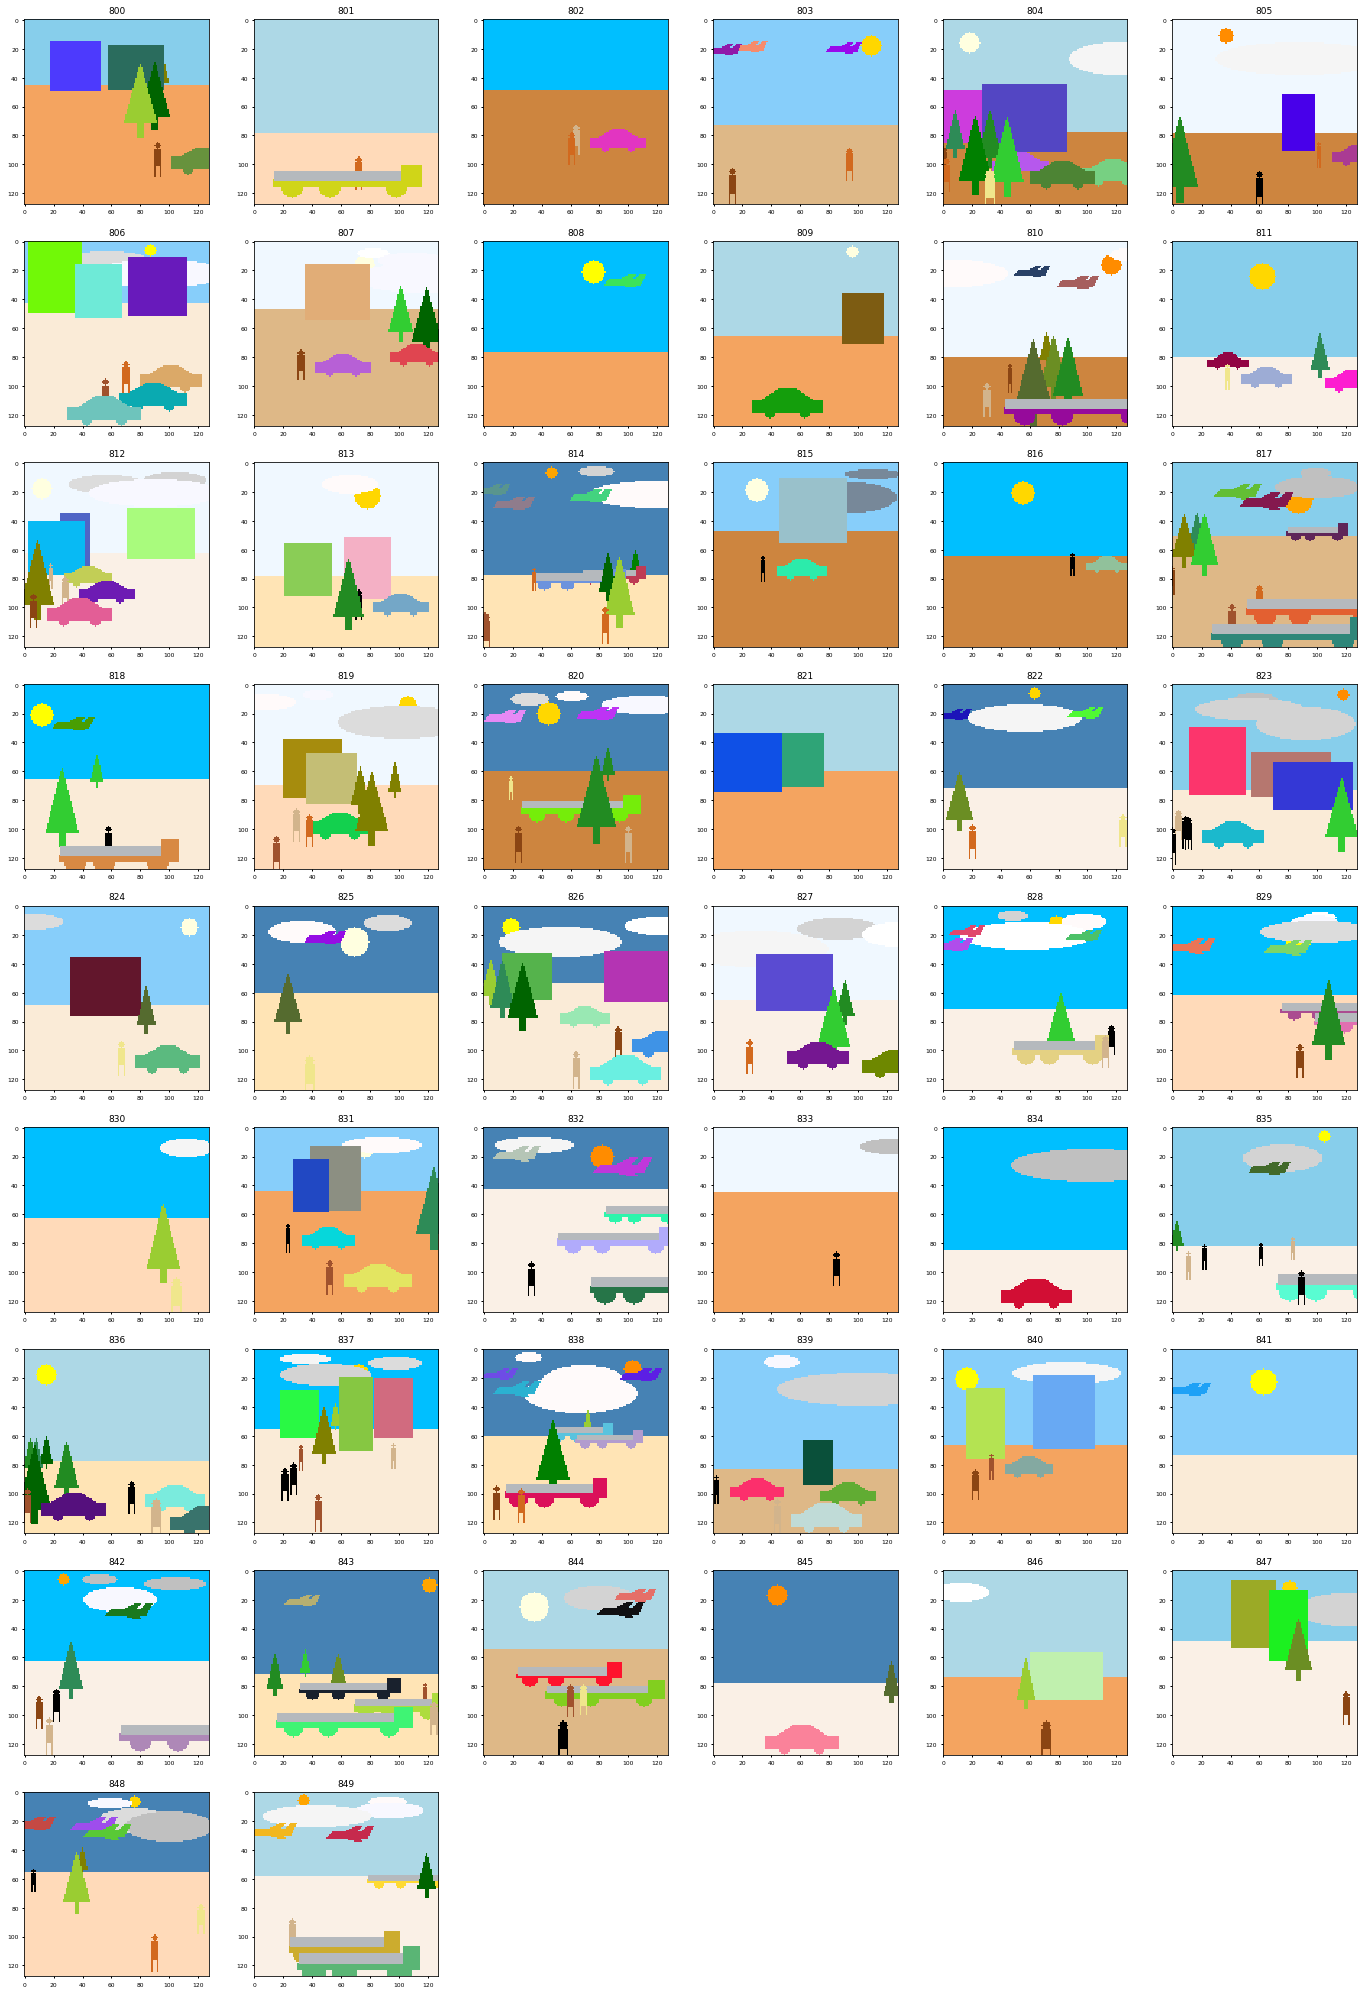

In [109]:
# image_list = list(range(16534, 16570))
# image_list = [ 600 , 1974, 619, 1112,  606, 1783,  225, 2237,  356,  807, 2099, 1311, 1786, 2260,  814,  739, 1368, 1127,  254, 2224, 1337]
image_list = list(range(800, 850))
image_titles = [str(i) for i in image_list]
images = get_image_batch(dataset_test, image_list)
visualize.display_images(images, titles = image_titles, cols = 6, width = 24)

### Get next image from generator and display 

image id :  16567
 Image_id    :  16567  Reference:  http://cocodataset.org/#explore?id=572110 Coco Id: 572110
 Image meta  :  [16567   361   640     3   223     0   801  1024]
 Class ids   :  (12,)    [44 44 45 45 46 70 40 44 44 44 73 77]
 Class Names :  ['knife', 'knife', 'spoon', 'spoon', 'bowl', 'oven', 'bottle', 'knife', 'knife', 'knife', 'refrigerator', 'scissors']
image id :  16567
 Image_id    :  16567  Reference:  http://cocodataset.org/#explore?id=572110 Coco Id: 572110
 Image meta  :  [16567   361   640     3   223     0   801  1024]
 Class ids   :  (12,)    [44 44 45 45 46 70 40 44 44 44 73 77]
 Class Names :  ['knife', 'knife', 'spoon', 'spoon', 'bowl', 'oven', 'bottle', 'knife', 'knife', 'knife', 'refrigerator', 'scissors']


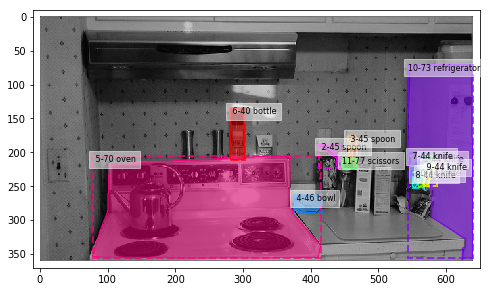

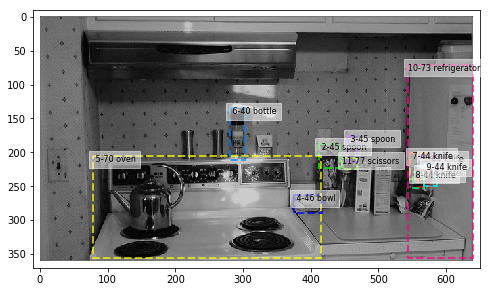

In [147]:
image_id = 16534
image_id = 16567
# test_batch_x, test_batch_y = next(test_generator)
# display_training_batch(dataset_test, test_batch_x, masks = True)
# test_batch_x = get_inference_batch(dataset_test, mrcnn_model ,generator = test_generator, display = True)
test_batch_x = get_inference_batch(dataset_test, mrcnn_model.config , image_ids = image_id, display = True, masks = True)
test_batch_x = get_inference_batch(dataset_test, mrcnn_model.config , image_ids = image_id, display = True, masks = False)

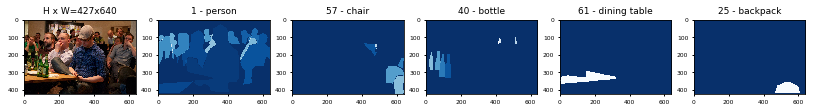

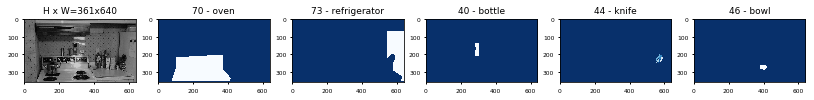

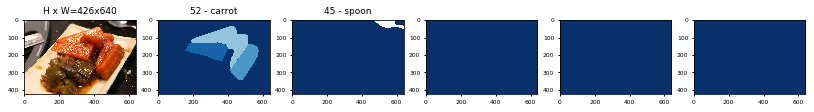

In [148]:
visualize.display_image_masks(dataset_test, [16534,16567,16536])

### Get images using a list of image ids

[         1          1          2          3          4          4          6]

GT_BOXES for image  840
--------------------------------------------------------------------------------
        class              |                              
seq  id name               |  Y1  X1  Y2  X2     CX     CY    AREA
--------------------------------------------------------------------------------
  0   1 person             |   73   32   91   35    33.5   82.0    54.00
  1   1 person             |   84   20  105   25    22.5   94.5   105.00
  2   2 car                |   75   43   90   76    59.5   82.5   495.00
  3   3 sun                |   13    8   29   25    16.5   21.0   272.00
  4   4 building           |   19   62   70  105    83.5   44.5  2193.00
  5   4 building           |   28   16   77   43    29.5   52.5  1323.00
  6   6 cloud              |   10   48   24  123    85.5   17.0  1050.00



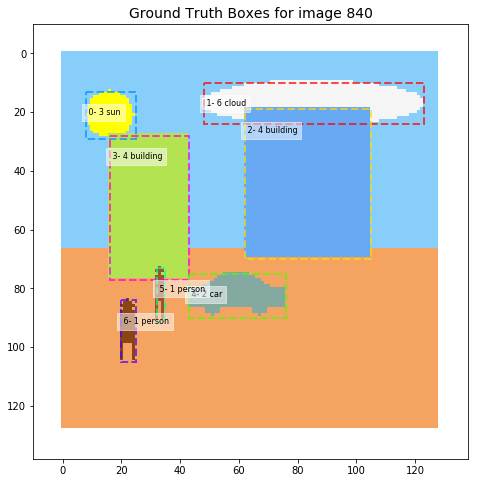

In [110]:
image_id = 840
vis2.display_gt_bboxes(dataset_test, mrcnn_model.config, image_id)
# image_batch = get_image_batch(dataset_test, image_id, display=True)
# test_batch_x = get_training_batch(dataset_test, mrcnn_model.config, IMAGE_LIST)
# inference_batch, image_batch = get_inference_batch(dataset_test, mrcnn_model, IMAGE_LIST, display = True)

### Other display functions

#### Display top masks for sample images

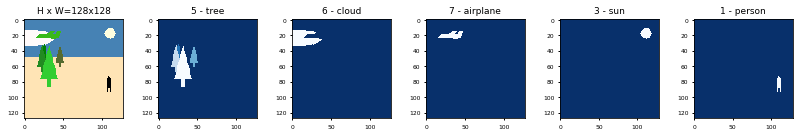

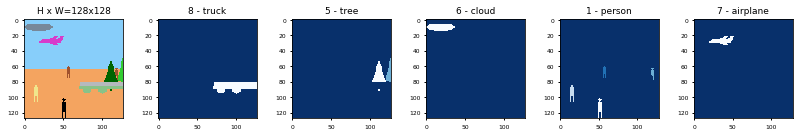

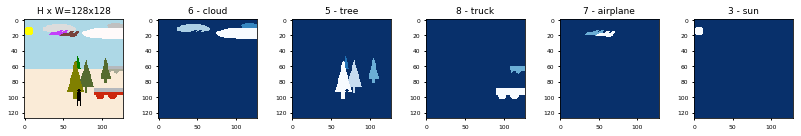

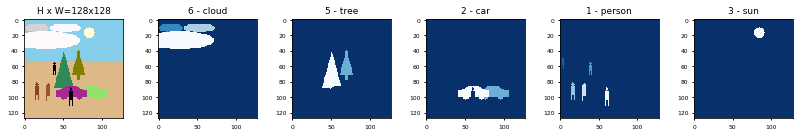

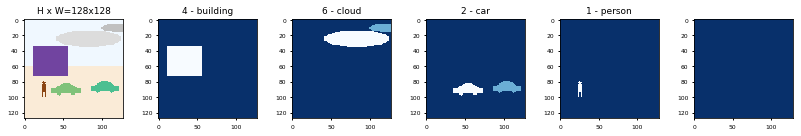

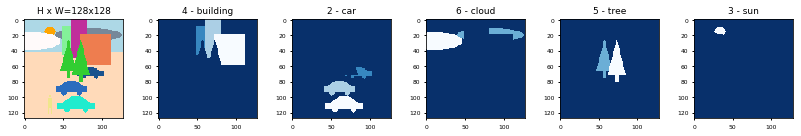

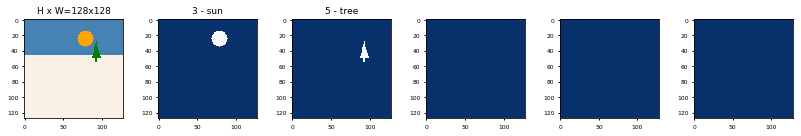

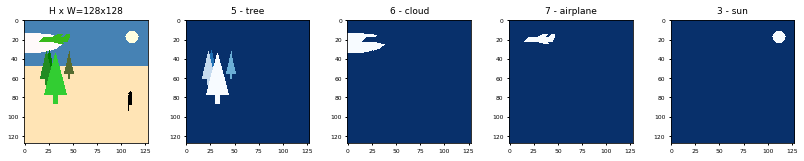

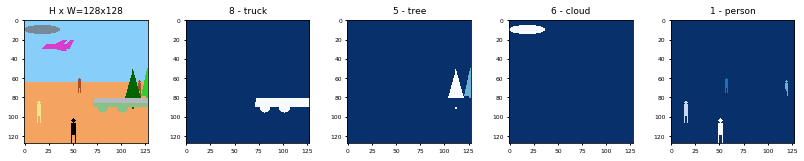

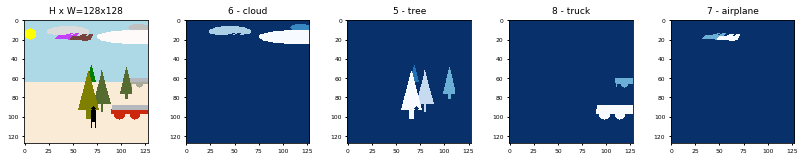

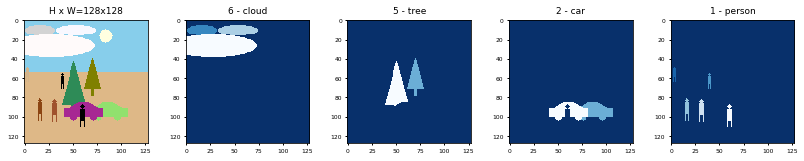

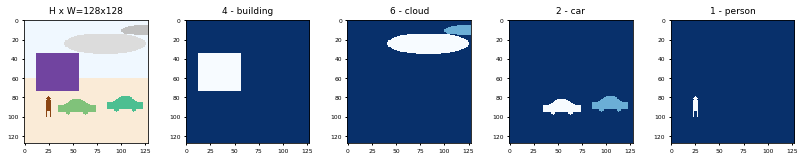

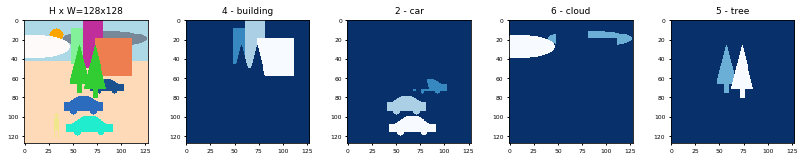

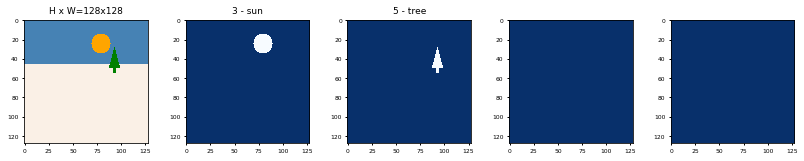

In [14]:
# Load and display random samples
image_ids = np.random.choice(dataset_test.image_ids, 7)
visualize.display_image_masks(dataset_test, image_ids)
for image_id in image_ids:
    image = dataset_test.load_image(image_id)
    mask, class_ids = dataset_test.load_mask(image_id)
    visualize.display_top_masks(image, mask, class_ids, dataset_test.class_names)

####  Dispaly a random image from dataset_test

In [ ]:
# Load random image and mask. ### 27711 persons and boats
image_id = np.random.choice(dataset_test.image_ids)
_ = batch_input = demo_image(dataset_test, mrcnn_model.config, image_id, masks = False)

#### Get an image and place into train_batch_x

In [ ]:
IMAGE_LIST= [30531]
batch_input = get_training_batch(dataset_test, mrcnn_model.config, 30531, masks = False)

## FCN detection using `fcn.detect()` - run `image_batch` Image List through model pipeline

In [111]:

fcn_results = run_fcn_detection(fcn_model, mrcnn_model, dataset_test, image_ids= image_id, verbose =0)


#### display output elements

In [70]:
np.set_printoptions(linewidth=180,precision=4,threshold=10000, suppress = True)
print(' Length of fcn_results: ', len(fcn_results))
f = fcn_results[0]
print(len(f.keys()), f.keys())
for i in f.keys():
    print('   {:.<25s}  {}'.format(i , f[i].shape))

 Length of fcn_results:  1
21 dict_keys(['orig_image_meta', 'fcn_sm', 'gt_bboxes', 'class_ids', 'detection_ind', 'image', 'pr_hm_scores', 'molded_rois', 'pr_hm', 'molded_image', 'image_meta', 'pr_scores', 'gt_class_ids', 'pr_scores_by_class', 'fcn_hm', 'fcn_scores', 'fcn_scores_by_class', 'rois', 'scores', 'fcn_hm_scores', 'detections'])
   orig_image_meta..........  (17,)
   fcn_sm...................  (128, 128, 9)
   gt_bboxes................  (4, 4)
   class_ids................  (4,)
   detection_ind............  (4,)
   image....................  (128, 128, 3)
   pr_hm_scores.............  (9, 64, 24)
   molded_rois..............  (4, 4)
   pr_hm....................  (128, 128, 9)
   molded_image.............  (128, 128, 3)
   image_meta...............  (17,)
   pr_scores................  (4, 24)
   gt_class_ids.............  (4,)
   pr_scores_by_class.......  (9, 64, 24)
   fcn_hm...................  (128, 128, 9)
   fcn_scores...............  (4, 24)
   fcn_scores_by_class...... 

## Display Output Scores

#### display MRCNN scores 

In [66]:
import mrcnn.visualize_2 as vis2
vis2.display_mrcnn_scores(f, class_names, display= False)
# vis2.display_mrcnn_style1(f, class_names, display= False)
# vis2.display_mrcnn_style2(f, class_names, display= False)
# vis2.display_pr_hm_scores(f, class_names, display= False)
# vis2.display_pr_hm_scores_box_info(f, class_names, display= False)


 Display pr_scores ; (4, 24)
PR_SCORES from fcn/mrcnn_results:
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
                              |   |                |        MRCNN score 0       |          MRCNN score 1             |           MRCNN score 2            |                           
          class               |TP/| mrcnn  normlzd |  gaussian   bbox   nrm.scr*|  ga.sum    mask     score   norm   |  ga.sum    mask     score   norm   |                           
    seq  id name              | FP| score   score  |    sum      AREA   gau.sum |  in mask   sum              score  |  in mask   sum              score  |  X1  Y1  X2  Y2   CX   CY 
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  0  64  4 build

#### display FCN scores 

In [65]:
# vis2.display_fcn_scores(f, class_names, display= False)
vis2.display_fcn_scores_box_info(f, class_names)
vis2.display_fcn_scores_box_info2(f, class_names)
# vis2.display_fcn_scores_by_class(f, class_names)



--------------------------------------------------
Display fcn_scores_info w/ bbox information : (4, 24)
--------------------------------------------------
Classes   --  :  [         2          3          4          5]
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
                                                         |                                                 |    (COVAR)    |               CLIP REGION   
BOX     class                                            |                   Width   Height                |      SQRT     |      FROM/TO               FROM/TO 
seq  id     name              Y1/X1              Y2/X2   |    CX / CY         (W)  ~  (H)      AREA        |  W/2     H/2  |  X1/Y1    X2/Y2   A |  X1/Y1   X2/Y2   A
--------------------------------------------------------------------------------------------------------------------------

#### display both scores together

In [67]:
vis2.display_both_scores(f, class_names, display = False)
# vis2.display_both_scores_style1(f, class_names, display = False)
# vis2.display_both_scores_style2(f, class_names, display = False)
# vis2.display_both_scores_style3(f, class_names, display = False)



---------------------------------------------
Scores from fcn/mrcnn_results (style3): 
---------------------------------------------


Scores from fcn/mrcnn_results:   (top line MRCNN, bottom line FCN) 
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
                              |   |                |     MRCNN / FCN score 0    |         MRCNN / FCN score 1        |        MRCNN / FCN score 2         | 
          class               |TP/| mrcnn  normlzd |  gaussian   bbox   nrm.scr*|  ga.sum    mask     score   norm   |  ga.sum    mask     score   norm   | 
    seq  id name              | FP| score   score  |    sum      area   gau.sum |  in mask   sum              score  |  in mask   sum              score  |  Y1  X1  Y2  X2   AREA  
----------------------------------------------------------------------------------------------------------------------------

##  FCN detection using `fcn.run_inference_pipeline()` - run `IMAGE_LIST` through detection pipeline

Loading 2 images
image                    shape: (398, 640, 3)         min:    0.00000  max:  255.00000
image                    shape: (428, 640, 3)         min:    0.00000  max:  255.00000


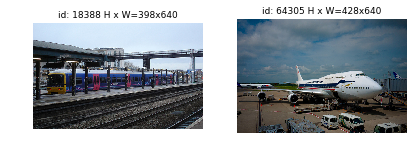

call mrcnn predict()
    Wrapper for Detection Layer : call()  <class 'list'> 4
     rpn_proposals_roi  : (2, 1000, 4) <class 'numpy.ndarray'>
     mrcnn_class.shape  : (2, 1000, 81) <class 'numpy.ndarray'>
     mrcnn_bboxes.shape : (2, 1000, 81, 4) <class 'numpy.ndarray'>
     image_meta         : (2, 89) <class 'numpy.ndarray'>


 Detections are:
[[517.     705.     582.     730.       1.       0.992 ]
 [454.      12.     614.     926.       7.       0.9695]
 [460.      77.     621.     243.       6.       0.7139]
 [521.     699.     571.     713.       1.       0.5538]
 [521.     723.     578.     738.       1.       0.5355]]


 Detections are:
[[ 436.       50.      686.      879.        5.        0.9997]
 [ 485.      936.      528.     1001.        5.        0.9936]
 [ 545.        0.      586.      220.        5.        0.9925]
 [ 742.      506.      838.      616.        8.        0.9227]
 [ 757.      284.      853.      554.        8.        0.9176]
 [ 652.      521.      716.  

In [81]:
# mrcnn_model.layer_info()
# fcn_model.layer_info()
# # IMAGE_LIST = [18388, 64305, 1507]
# # IMAGE_LIST = [24627, 33758] # , 6749]
IMAGE_LIST = [18388, 64305] #1507]
# IMAGE_LIST = [88857, 74451]
fcn_results = fcn_model.run_inference_pipeline(mrcnn_model, dataset_test, IMAGE_LIST, verbose = True)

## Visualize results from `fcn.run_inference_pipeline()`



---------------------------------------------
Scores from fcn/mrcnn_results (style3): 
---------------------------------------------


Scores from fcn/mrcnn_results:   (top line MRCNN, bottom line FCN) 
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
                              |   |                |     MRCNN / FCN score 0    |         MRCNN / FCN score 1        |        MRCNN / FCN score 2         | 
          class               |TP/| mrcnn  normlzd |  gaussian   bbox   nrm.scr*|  ga.sum    mask     score   norm   |  ga.sum    mask     score   norm   | 
    seq  id name              | FP| score   score  |    sum      area   gau.sum |  in mask   sum              score  |  in mask   sum              score  |  Y1  X1  Y2  X2   AREA  
----------------------------------------------------------------------------------------------------------------------------

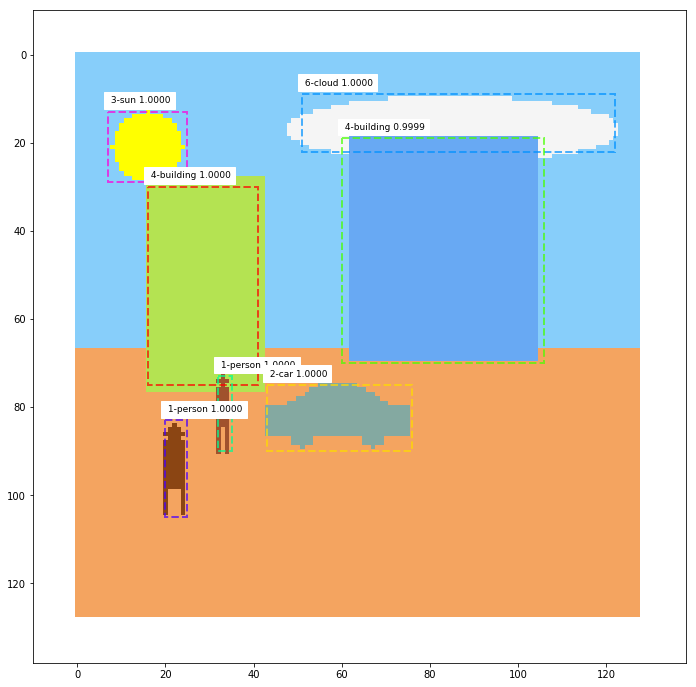

In [114]:
img_id = 0
f = fcn_results[0]
coco_id = dataset_test.image_info[image_id]['id']
image_id=f['orig_image_meta'][0]
np.set_printoptions(linewidth=180,precision=4,threshold=10000, suppress = True)
vis2.display_both_scores(f, class_names, display = False)
vis3.display_instances_w_scores(f, class_names = class_names, score_column = 5, score_range=(0.50, 1.05))

## 2D heatmaps

In [115]:
img_id = 0
f = fcn_results[0]
coco_id = dataset_test.image_info[image_id]['id']
image_id=f['orig_image_meta'][0]
gt_class_ids = np.unique(f['gt_class_ids']).astype(int).tolist() 
pr_class_ids = np.unique(f['pr_scores'][:,4]).astype(int).tolist()
fcn_class_ids = np.unique(f['fcn_scores'][:,4]).astype(int).tolist()
print('Image id: ',image_id, ' Coco ID: ', coco_id)
print('GT  class ids: ', gt_class_ids)
print('PR  class ids: ', pr_class_ids)
print('FCN class ids: ', fcn_class_ids)

Image id:  840  Coco ID:  840
GT  class ids:  [1, 2, 3, 4, 6]
PR  class ids:  [1, 2, 3, 4, 6]
FCN class ids:  [1, 2, 3, 4, 6]


840
Class Ids :  [         1          2          3          4          6]
 Scaling options are 'all', 'class'/'each', 'clip', or 'none' 
 image_bw shape:  (128, 128) uint8
 downscaled_image_bw shape:  (128, 128) float64
 Shape of Z:  (128, 128, 9)  boxes:  (9, 64, 24)
 Image Id:  0  Display classes: [1, 2, 3, 4, 5, 6, 7, 8]
 min_z_all shape: ()  min_z_all: 0.0  max_z_all: () max_z_all: 1.0
 min_z_cls shape: (1, 1, 9)  max_z_cls shape: (1, 1, 9)
 SCALING == none 
 rows   1  columns : 9 boxes.shape :  (9, 64, 24)


/home/kbardool/anaconda3/envs/TFG/lib/python3.5/site-packages/skimage/transform/_warps.py:84: UserWarning: The default mode, 'constant', will be changed to 'reflect' in skimage 0.15.
  warn("The default mode, 'constant', will be changed to 'reflect' in "


ending idx is : 7


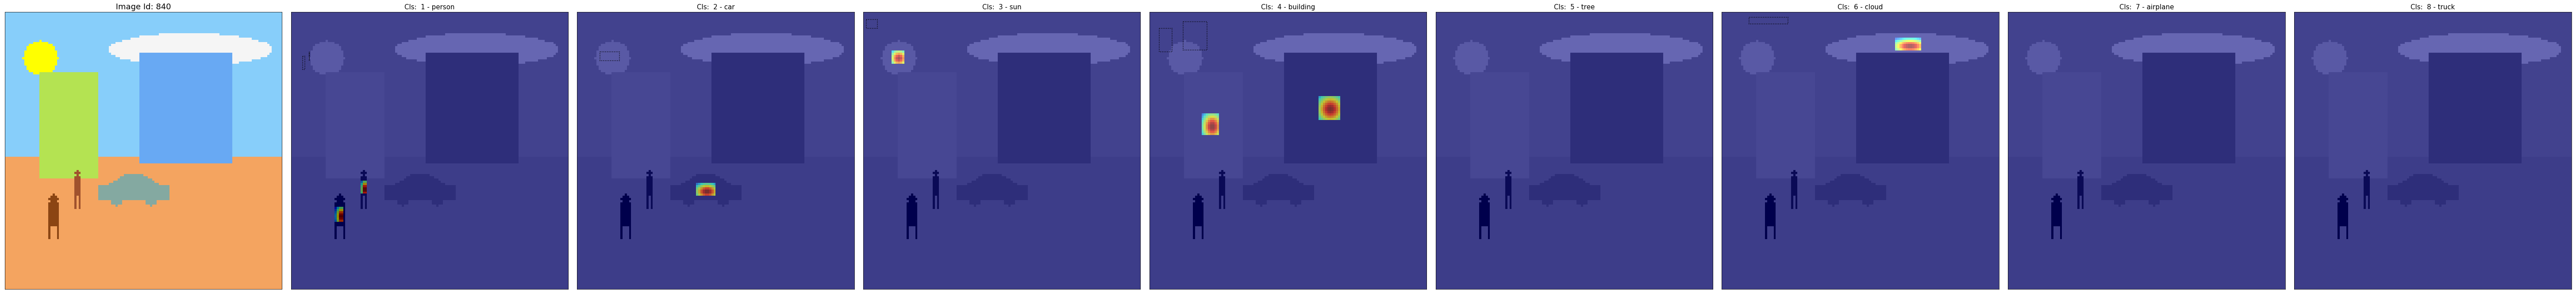

In [116]:
cols = None
print(coco_id)
pr_class_ids = np.unique(f['class_ids'])
print('Class Ids : ', pr_class_ids)
cls_ids     = [ 1, 2, 3, 4, 5, 6, 7, 8] 

# fig = vis3.plot_2d_heatmap(f['pr_hm'], f['pr_scores_by_class'], img_id, cls_ids, columns = cols, num_bboxes = 0,
#                           class_names = class_names, scale = 4, scaling = 'none')
fig = vis3.plot_2d_heatmaps_poster(fcn_results, img_id, hm = 'pr_hm', class_ids = cls_ids, columns = cols, config = mrcnn_model.config,
                          class_names = class_names, scale = 4, scaling = 'none')
fig.savefig('pr_hm_i'+str(coco_id)+'.png')

 Scaling options are 'all', 'class'/'each', 'clip', or 'none' 
 Shape of Z:  (128, 128, 9)  boxes:  (9, 64, 24)
 Image Id:  0  Display classes: [1, 2, 3, 4, 5, 6, 7, 8]
 min_z_all shape: ()  min_z_all: -4.018359  max_z_all: () max_z_all: 1.3861799
 min_z_cls shape: (1, 1, 9)  max_z_cls shape: (1, 1, 9)
 SCALING == none 
 rows   1  columns : 9 boxes.shape :  (9, 64, 24)


/home/kbardool/anaconda3/envs/TFG/lib/python3.5/site-packages/skimage/transform/_warps.py:84: UserWarning: The default mode, 'constant', will be changed to 'reflect' in skimage 0.15.
  warn("The default mode, 'constant', will be changed to 'reflect' in "


ending idx is : 7


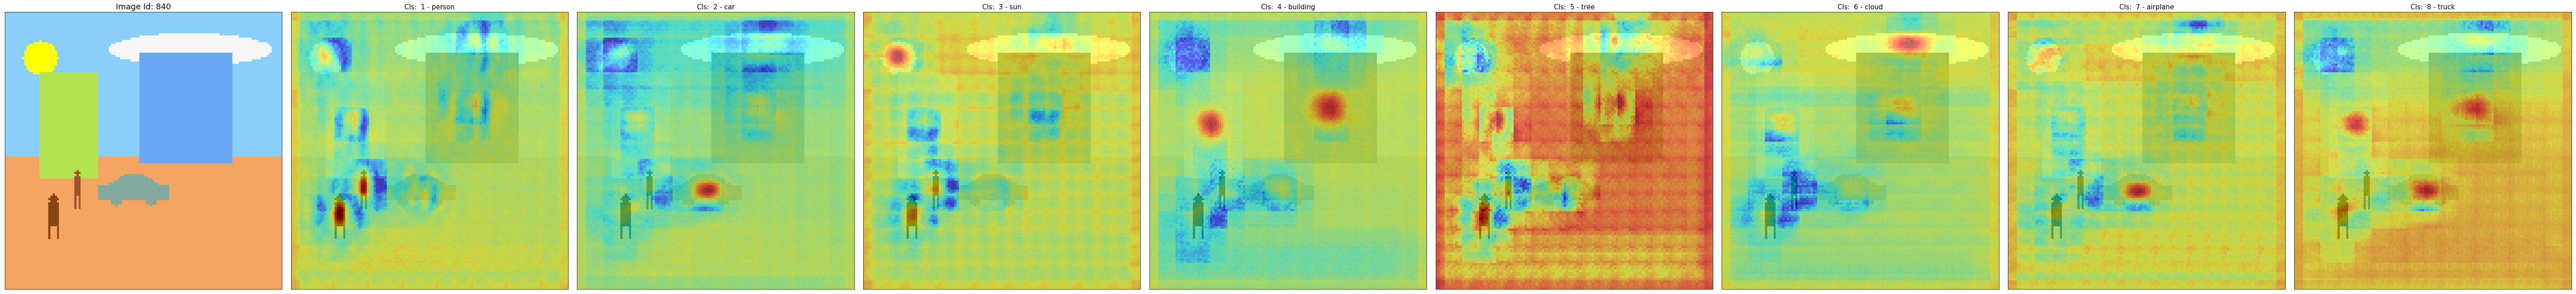

In [117]:
img_id = 0
pr_class_ids = np.unique(f['class_ids'])
# cls_ids = pr_class_ids
# fig = visualize.plot_2d_heatmap(f['fcn_hm'], f['fcn_scores_by_class'], img_id, cls_ids, columns = 5, num_bboxes = 0,
#                           class_names = class_names, scale = 4, scaling = 'none')
# for scale in ['all', 'class', 'none', 'clip']:
scale = 'none'
fig = vis3.plot_2d_heatmaps_poster(fcn_results, 0, hm = 'fcn_hm', class_ids= cls_ids, columns = cols, num_bboxes = 0, config = mrcnn_model.config,
                          class_names = class_names, scale = 4, scaling = scale)

fig.savefig('fcn_hm_i'+str(coco_id)+'.png')

### Overlay image with pred_heatmaps

class ids:  [2, 3, 4, 5]
 Scaling options are:  'all', 'class'/'each' , or  'clip' 
 heatmap shape:  (128, 128, 9)  Bounding boxes shape:  (9, 64, 24)
Display classes: [1, 2, 3, 4, 5, 6, 7, 8]


/home/kbardool/anaconda3/envs/TFG/lib/python3.5/site-packages/skimage/transform/_warps.py:84: UserWarning: The default mode, 'constant', will be changed to 'reflect' in skimage 0.15.
  warn("The default mode, 'constant', will be changed to 'reflect' in "


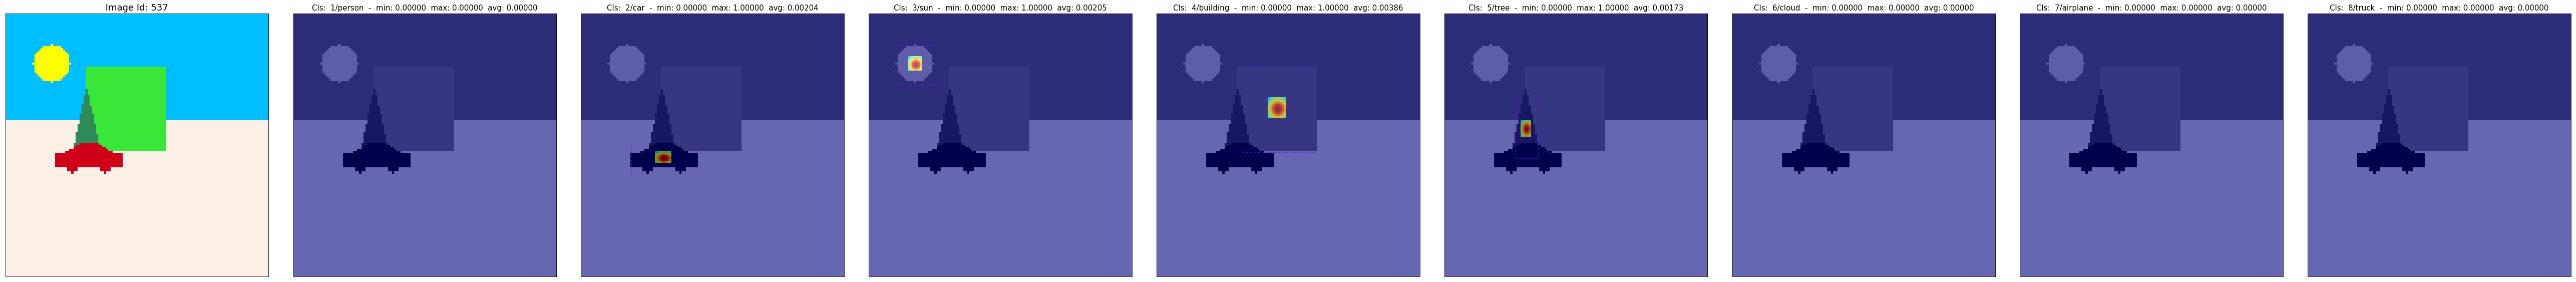

In [79]:
class_ids = np.unique(f['pr_scores'][:,4]).astype(int).tolist()
print('class ids: ', class_ids)
fig = vis3.inference_heatmaps_display_poster(fcn_results, image_id = 0, 
                           class_ids = cls_ids, 
                           class_names = dataset_test.class_names, 
                           hm = 'pr_hm' ,
                           config = mrcnn_model.config,
                           columns = cols,
                           scaling = 'class')
fig.savefig('pr_hm_i'+str(coco_id)+'_orig_size.png')

 Scaling options are:  'all', 'class'/'each' , or  'clip' 
 heatmap shape:  (128, 128, 9)  Bounding boxes shape:  (9, 64, 24)
Display classes: [1, 2, 3, 4, 5, 6, 7, 8]


/home/kbardool/anaconda3/envs/TFG/lib/python3.5/site-packages/skimage/transform/_warps.py:84: UserWarning: The default mode, 'constant', will be changed to 'reflect' in skimage 0.15.
  warn("The default mode, 'constant', will be changed to 'reflect' in "


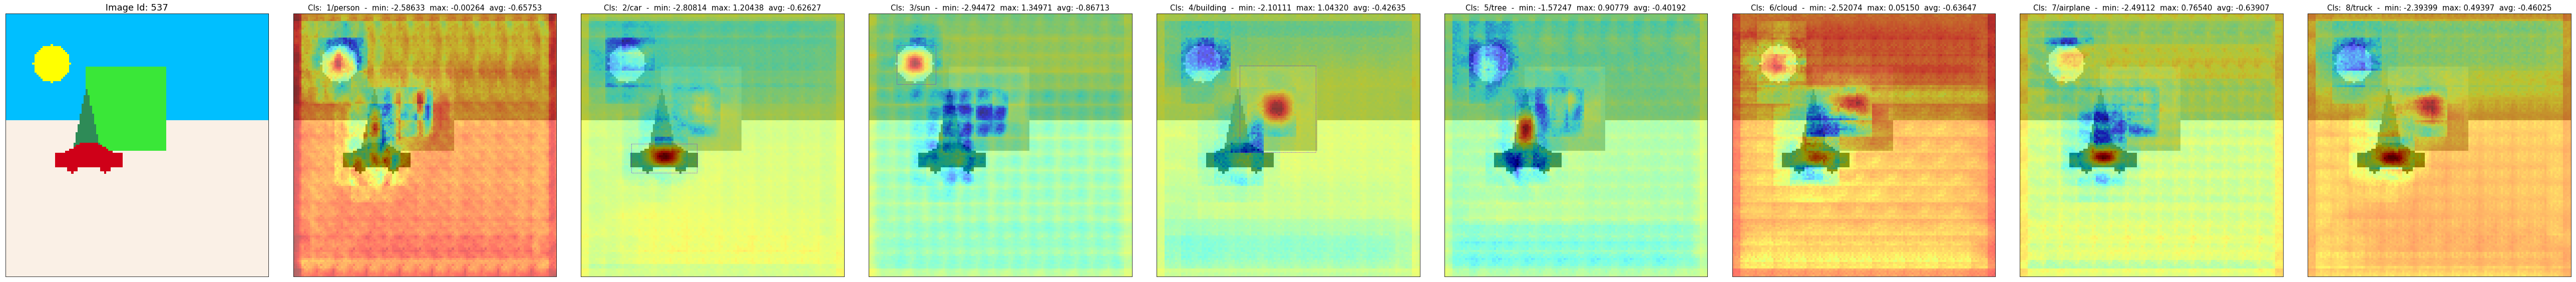

In [80]:
fig = vis3.inference_heatmaps_display_poster(fcn_results, image_id = 0, 
                           class_ids = cls_ids, 
                           class_names = dataset_test.class_names, 
                           hm = 'fcn_hm' ,
                           config = mrcnn_model.config,
                           columns = cols,
                           scaling = 'class')
fig.savefig('fcn_hm_i'+str(coco_id)+'_orig_size.png')

### Overlay image with fcn_heatmaps

In [ ]:
from mrcnn.visualize import display_heatmaps, display_heatmaps_fcn, display_heatmaps_mrcnn, inference_heatmaps_display
# visualize.display_image_bw(image)
# print(model_gt_heatmap_scores.shape)
class_ids = np.unique(f['pr_scores'][:,4]).astype(int).tolist()
print('class ids: ', class_ids)
inference_heatmaps_display(fcn_results, 0, class_ids = class_ids, class_names = coco_class_names, hm = 'fcn_hm' ,config = mrcnn_model.config, scaling = 'class') 
# , display_heatmaps_mrcnn(train_batch_x, model_output, 0, hm = 'pr',  

### Overlay image with pr_heatmaps and fcn_heatmaps

 Scaling options are: 'all', 'class', 'each' , or  'clip' : 
 heatmap shape:  (256, 256, 81)
 Bounding boxes shape:  (81, 200, 24)
Image shape : (361, 640, 3)  class_ids: [40 44 45 46 69 70 73 74 76]


/home/kbardool/anaconda3/envs/TFG/lib/python3.5/site-packages/skimage/transform/_warps.py:84: UserWarning: The default mode, 'constant', will be changed to 'reflect' in skimage 0.15.
  warn("The default mode, 'constant', will be changed to 'reflect' in "


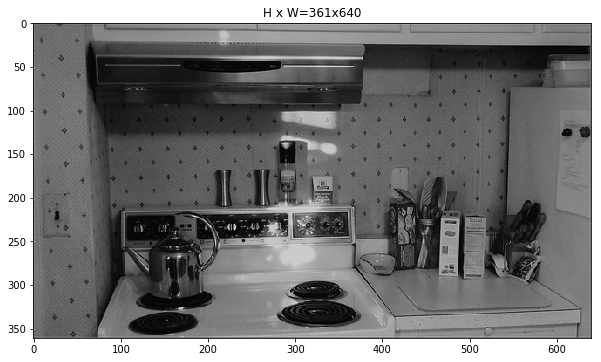

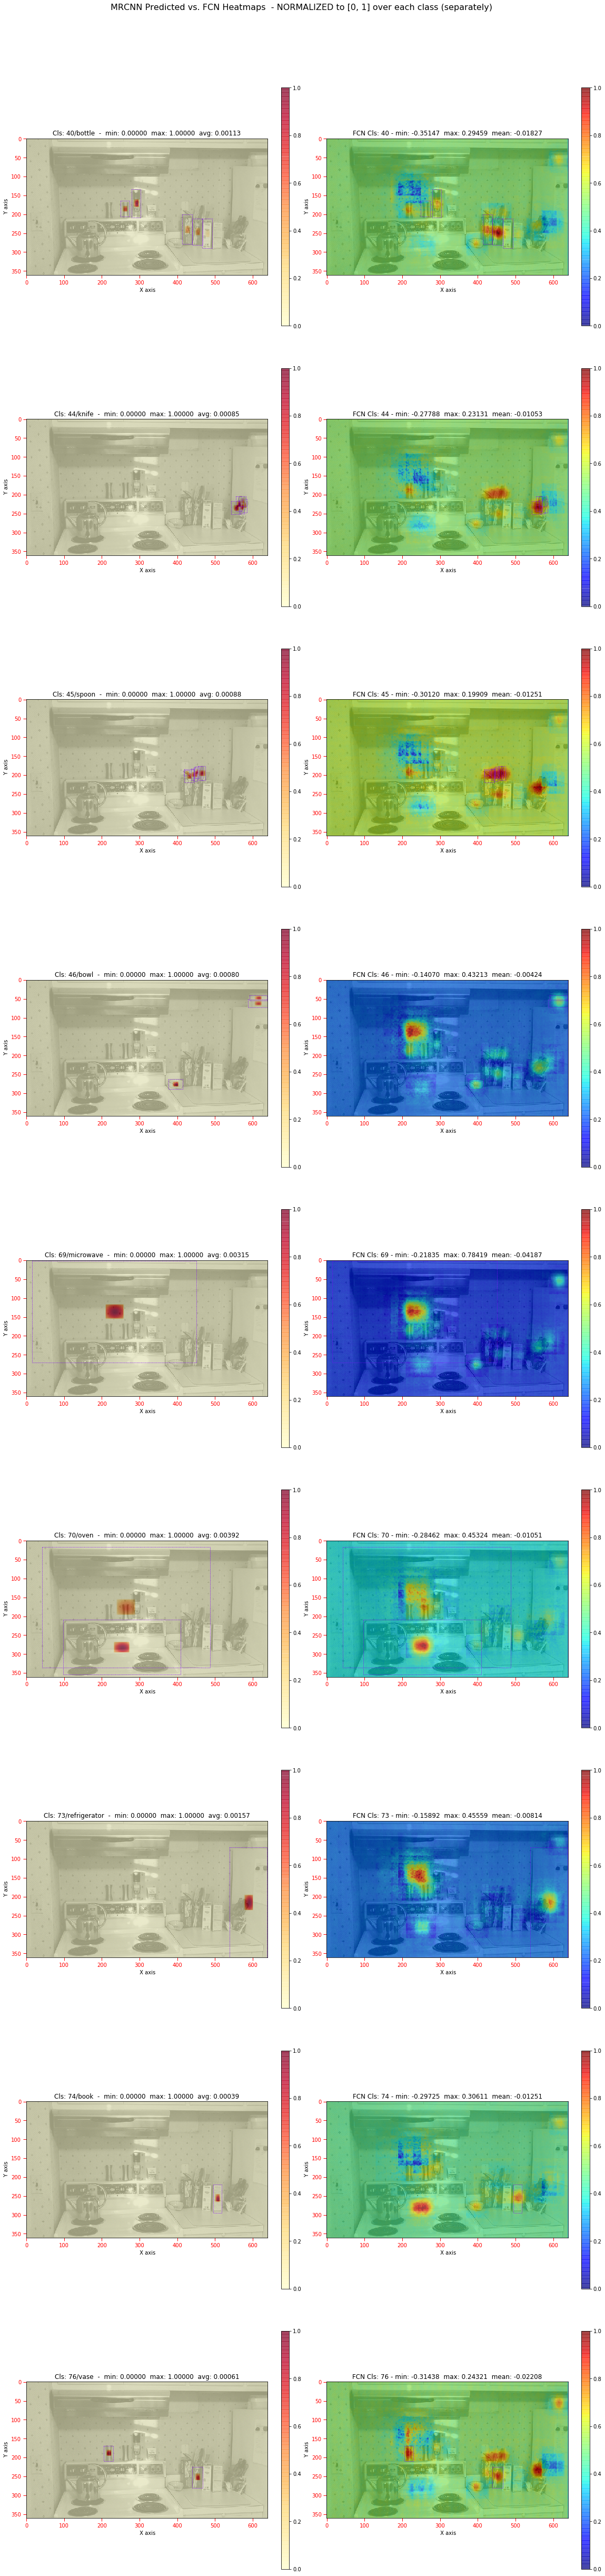

In [259]:
visualize.inference_heatmaps_compare(fcn_results, image_id = 0 , hm = 'fcn_hm', 
                     config = mrcnn_model.config, class_ids = pr_class_ids, class_names = class_names, scaling = 'each')

####  3D comparative display `pred_heatmap` / `fcn_heatmap` 

3
Image : 0  Predicted    ClassIds: [0, 1, 40, 42, 57, 61, 66]
Display classes: [0, 1, 40, 42, 57, 61, 66]
 image height/width  256 256
shape pos  (256, 256, 2) shape Z1:  (256, 256, 81) shape Z2: (256, 256, 81)
 min_z1_all shape: ()  min_z1_all: 0.0  max_z1_all: () max_z1_all: 1.0
 min_z2_all shape: ()  min_z2_all: -0.43362135  max_z2_all: () max_z2_all: 1.1540563
ttl:  HM1 Img:  0 Cls:  0/BG  -  min: 0.00000  max: 0.00000
ttl:  HM2 Img:  0 Cls:  0/BG  -  min: -0.09116  max: 0.08676
ttl:  HM1 Img:  0 Cls:  1/person  -  min: 0.00000  max: 1.00000
ttl:  HM2 Img:  0 Cls:  1/person  -  min: -0.18603  max: 1.15406
ttl:  HM1 Img:  0 Cls: 40/bottle  -  min: 0.00000  max: 1.00000
ttl:  HM2 Img:  0 Cls: 40/bottle  -  min: -0.16114  max: 0.47081
ttl:  HM1 Img:  0 Cls: 42/cup  -  min: 0.00000  max: 1.00000
ttl:  HM2 Img:  0 Cls: 42/cup  -  min: -0.14963  max: 0.42515
ttl:  HM1 Img:  0 Cls: 57/chair  -  min: 0.00000  max: 1.00000
ttl:  HM2 Img:  0 Cls: 57/chair  -  min: -0.11275  max: 0.25703
ttl

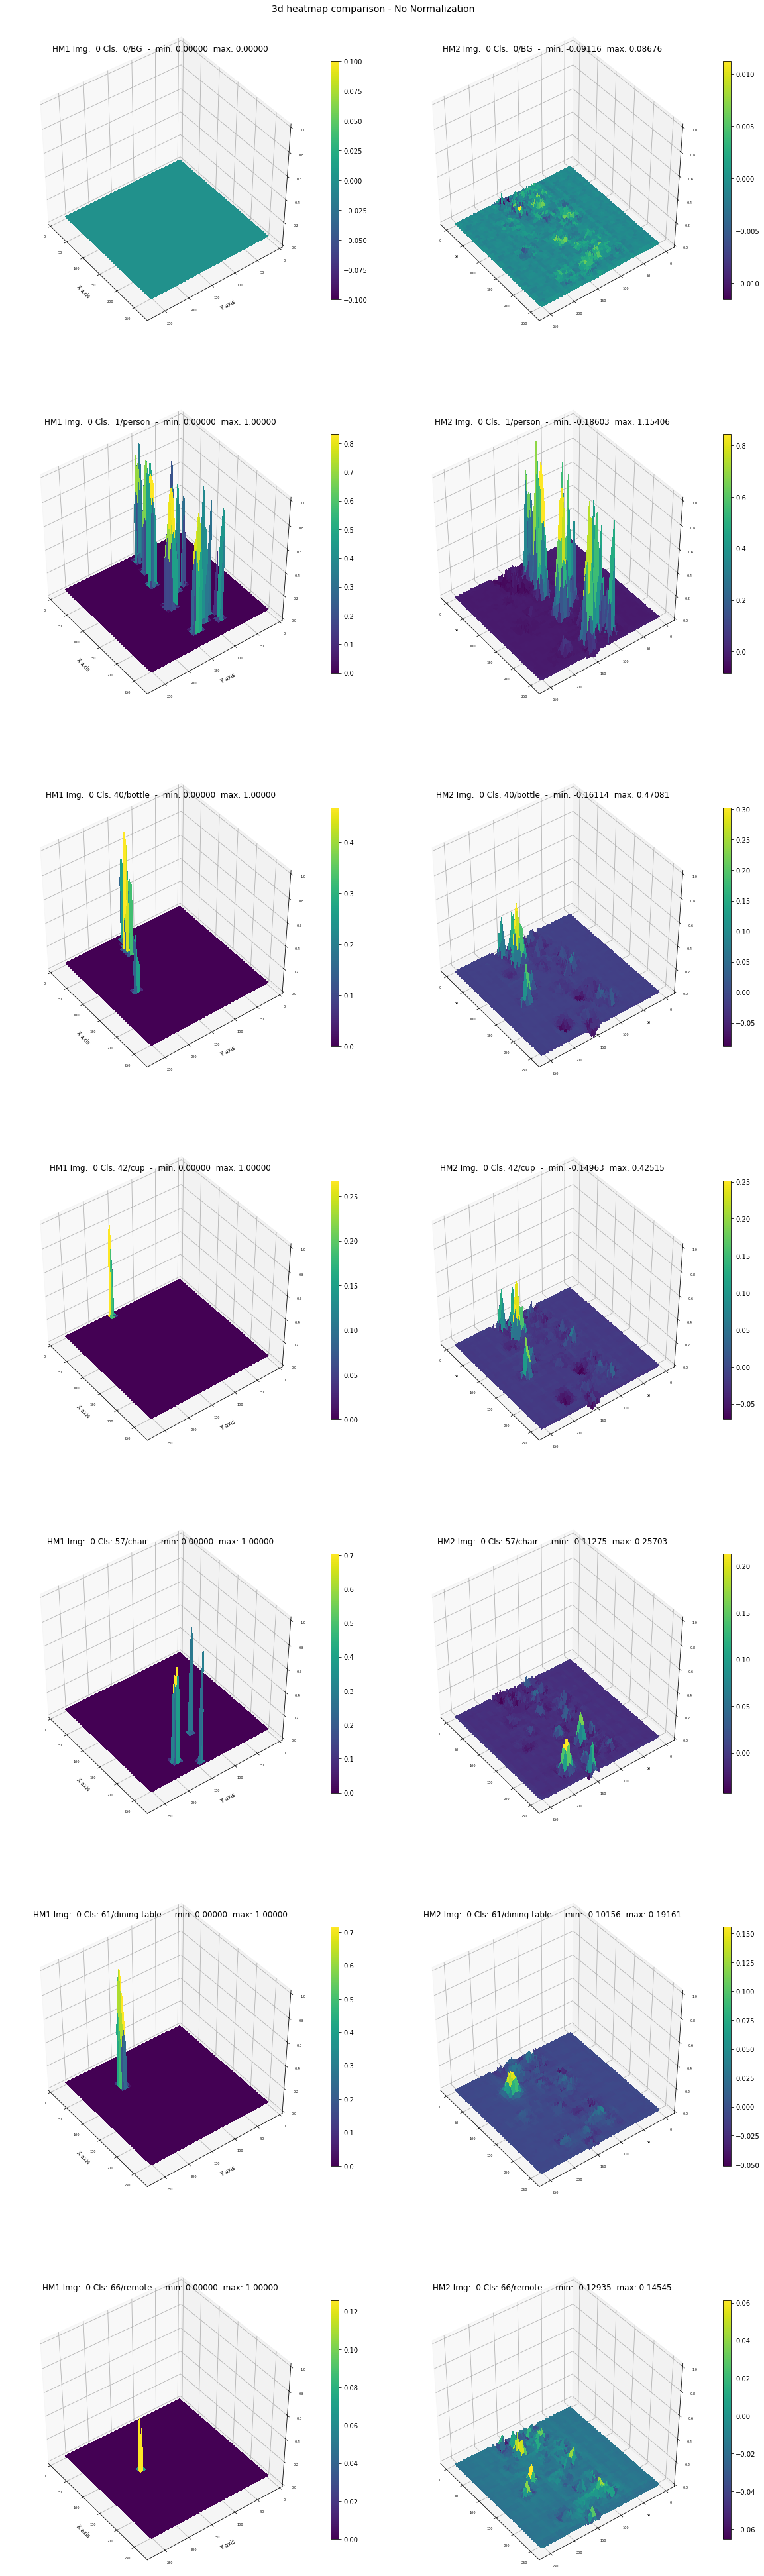

In [247]:
img_id = 0
r = fcn_results[img_id]
print(f['pr_scores_by_class'].ndim)
# print('Image id: ',image_id, ' Coco ID: ', dataset_train.image_info[image_id]['id'])
pr_class_ids = np.unique(f['pr_scores_by_class'][:,:,4]).astype(int).tolist()
print('Image : {}  Predicted    ClassIds: {}'.format(img_id, pr_class_ids))

visualize.plot_3d_heatmap_compare(f['pr_hm'], f['fcn_hm'], 0, class_ids = pr_class_ids, 
                            class_names = class_names, size=(8,8), zlim = 'all' , scaling = 'none')    